In [8]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from plots import *
from src import *

# Enable SVG in Jupyter notebooks.
%config InlineBackend.figure_formats = ['svg']

# Microwave-optical transduction fidelity

## Parameters

In [9]:
params = {
    'kappa_a' : 13.2,   # Optical linewidth [2π * GHz].
    'kappa_b' : 0.002,  # Microwave linewidth [2π * GHz].
    'omega_b' : 5.0,    # Microwave frequency [2π * GHz].
    'Delta' : 5.0,      # Optical detuning [2π * GHz].
    'eta_a' : 1.0,      # Optical collection efficiency.
    'eta_b' : 1.0,      # Microwave collection efficiency.
}

Delta_a = 1                                               # Optical detuning [2π * GHz].
z = 1 / abs(1 - (params['omega_b']/Delta_a)**2)           # Parametric coupling ratio from Eq. (24).

g_t = np.sqrt(params['kappa_a'] * params['kappa_b']) / 2    # Transduction rate.
g_s = z * g_t                                               # Two-mode squeezing rate.

In [10]:
# Initialise the transducer.
transducer = Transducer(**params)

# Noise moments at the central frequency.
S, L = transducer.channel(params['omega_b'], g_t, g_s)
moments = aout_moments(S, L)

## Characteristic function through the channel

Text(0.5, 0.98, 'GKP $|0\\rangle$,  $\\bar n = 10$')

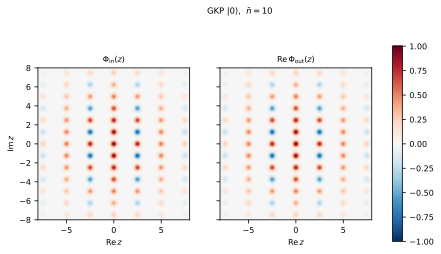

In [18]:
# Phi_out(z) = Phi_in(S12* z - S14 z*) * noise_factor(z) (src/fidelity.py).
# Swap Phi_in_demo for Phi_coherent / Phi_fock to see other states.
demo_nbar   = 10.0
Phi_in_demo = lambda w: Phi_gkp(w, demo_nbar)

R_view = 8.0                                   # viewing window, not the fidelity grid
ax1    = np.linspace(-R_view, R_view, 241)
Z      = ax1[None, :] + 1j*ax1[:, None]
Phi_i  = np.real(Phi_in_demo(Z))
Phi_o  = np.real(Phi_out(Z, Phi_in_demo, *moments))

fig, axs = plt.subplots(1, 2, figsize=(2.2*FIG_SIZES['onecol'], 1.15*FIG_SIZES['onecol']),
                        sharey=True)
vmax = np.abs(Phi_i).max()
for ax, data, title in ((axs[0], Phi_i, r'$\Phi_\mathrm{in}(z)$'),
                        (axs[1], Phi_o, r'$\mathrm{Re}\,\Phi_\mathrm{out}(z)$')):
    im = ax.imshow(data, extent=[-R_view, R_view, -R_view, R_view], origin='lower',
                   cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set(title=title, xlabel=r'$\mathrm{Re}\,z$')
axs[0].set_ylabel(r'$\mathrm{Im}\,z$')
fig.colorbar(im, ax=axs, shrink=0.9)
fig.suptitle(fr'GKP $|0\rangle$,  $\bar n = {demo_nbar:g}$')

## Numerics

In [12]:
# Mean photon numbers.
n_fock = np.arange(0, 11)             # Number states (integer)
nbar_coh = np.linspace(0.0, 10, 11)   # Coherent states (continuous)
nbar_gkp = np.linspace(0.0, 10.0, 11)  # GKP states (low n only; see below)

In [13]:
# Fock- and coherent-state fidelities. integration_grid sizes (R, N) to the
# state's characteristic function (Gaussian envelope, oscillation ~ sqrt(nbar)).
F_fock = np.array([
    fidelity(lambda w: Phi_fock(w, n), *moments, *integration_grid('fock', n))
    for n in n_fock
    ])

F_coh = np.array([
    fidelity(lambda w: Phi_coherent(w, np.sqrt(nbar)), *moments,
             *integration_grid('coherent', nbar))
    for nbar in nbar_coh
    ])

In [14]:
# GKP logical |0> state fidelity via the characteristic function (App. F1),
# square-lattice envelope Delta = 1/sqrt(2 nbar + 1) (src/gkp.gkp_envelope).
#
# Phi_gkp is an alternating-sign lattice comb: peak width Delta, but envelope
# only exp(-Delta**2 |z|**2 / 8), so integration_grid('gkp', .) uses a wide
# R ~ 1/Delta and a fine spacing Delta/4 (1 - F is a small residual left after
# the +/- peaks nearly cancel). Verified to 5 sig figs vs R=24 for nbar <= 5;
# cost ~ N**2 ~ nbar**2, hence the short low-n sweep, run in parallel.
def gkp_fidelity(nbar):
    return fidelity(lambda w: Phi_gkp(w, nbar), *moments,
                    *integration_grid('gkp', nbar))

F_gkp = np.array(Parallel(n_jobs=-1)(delayed(gkp_fidelity)(nbar) for nbar in nbar_gkp))

## Figure

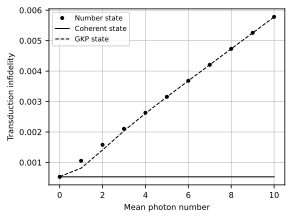

In [17]:
fig, axs = plt.subplots(
    nrows = 1,
    ncols = 1,
    figsize = (
        1.2 * FIG_SIZES['onecol'],
        0.9 * FIG_SIZES['onecol']
        ),
    sharey = True,
    )

label = fr'$\Delta_a/\omega_b = {Delta_a/params['omega_b']:g}$'
axs.plot(n_fock, 1-F_fock, c='k', marker='o', ls='', label='Number state')
axs.plot(nbar_coh, 1-F_coh, c='k', label='Coherent state')
axs.plot(nbar_gkp, 1-F_gkp, c='k', ls='--', label='GKP state')

# axs.semilogy()
axs.grid('both')
# axs.set_ylim(0, 1e-2)

axs.set_xlabel('Mean photon number')
axs.set_ylabel('Transduction infidelity')
axs.legend()

fig.tight_layout()
fig.savefig('fig/transduction.pdf', bbox_inches='tight')